# Transfer Learning for Biomedical Imaging
Tunneling Nanotubes (TNT) Detection in Cancer Cells

# Introduction

## Information About the Project

### Objective
The primary objective of this project is to apply transfer learning to detect tunneling nanotubes (TNTs) in fluorescence microscopy images of cancer cells. This is a binary patch classification task, where the model predicts whether a given image patch contains a TNT or not.

### Scope
The scope of the project focuses on building a complete, working end-to-end pipeline rather than achieving the highest possible accuracy. Key steps include:

* Extracting labeled image patches from a pair of provided large images.

* Building a custom dataset for binary classification.  

* Applying a transfer learning model (such as VGG16) to the data.  

* Training models on two different patch sizes (512 px and 256 px) and comparing their performance.

* Implementing checkpointing and evaluating a three-phase training schedule.

## Description of the Dataset

* Source: The data consists of fluorescence microscopy images. These images are captured from cancer cells that have been grown on a glass slide, labeled with fluorescent markers, and scanned using a fluorescence microscope. The dataset structure contains exactly two identical large images: original.png (the clean image) and annotated.png (the image with TNTs manually marked by yellow lines).

* Size: The original files are very large images comprising thousands of pixels per dimension. From these, the dataset will be generated by extracting smaller overlapping or non-overlapping patches, specifically sized at 512x512 pixels and 256x256 pixels.

* Type: This is image data (microscopy images).  

## Description of the Columns

* Target Variable: The target is a discrete binary label indicating the presence of a tunneling nanotube. The label is assigned as 1 if the patch contains a TNT (determined by the presence of yellow lines in the corresponding patch of the annotated image) and 0 if it contains no TNT. The dataset features a class imbalance, as most patches contain no TNTs.

* Feature Variables: The features are the image patches extracted exclusively from the original.png clean image. These features take the form of image pixel arrays (either 512x512 or 256x256 pixels)

# Task 1: Setup and Patch Creation

## Step 1.1: Import Libraries and Set Seeds

### Imports

In [234]:
import os
import shutil
import gc
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, Subset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import copy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split
#from monai.networks.nets import AttentionUnet
import segmentation_models_pytorch as smp
from torchinfo import summary
from torchvision.models import vgg16, VGG16_Weights

### Settings

In [167]:
import warnings
warnings.filterwarnings("ignore")

# Fix for VRAM fragmentation issues in PyTorch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
seed = 42
set_seed(seed)

# Configure device for GPU/CPU use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Step 1.2: (Optional) Shadow Removal

## Step 1.3: Patch Extraction

In [168]:
def setup_output_directories(output_dir):
    """
    Creates output directories for classes and returns their paths.
    """
    tnt_dir = os.path.join(output_dir, 'tnt')
    no_tnt_dir = os.path.join(output_dir, 'no_tnt')
    
    os.makedirs(tnt_dir, exist_ok=True)
    os.makedirs(no_tnt_dir, exist_ok=True)
    
    return tnt_dir, no_tnt_dir

In [169]:
def get_sliding_window_coords(height, width, patch_size, stride):
    """
    Generates a list of (x, y) coordinates for the sliding window.
    """
    coords = []
    for y in range(0, height - patch_size + 1, stride):
        for x in range(0, width - patch_size + 1, stride):
            coords.append((x, y))
    return coords

In [170]:
def contains_full_annotation(patch, lower_color, upper_color):
    """
    Returns True ONLY if the patch contains the yellow annotation AND 
    the annotation does not touch any of the patch's borders (not cut off).
    """
    hsv_patch = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_patch, lower_color, upper_color)
    
    # If there are no yellow pixels at all, return False
    if cv2.countNonZero(mask) == 0:
        return False
        
    # Check the 1-pixel outer perimeter of the patch
    touches_top    = np.any(mask[0, :] > 0)
    touches_bottom = np.any(mask[-1, :] > 0)
    touches_left   = np.any(mask[:, 0] > 0)
    touches_right  = np.any(mask[:, -1] > 0)
    
    # If yellow touches any border, the line was cut off -> return False
    if touches_top or touches_bottom or touches_left or touches_right:
        return False
        
    return True

In [171]:
def save_sample_previews(original_img, annotated_img, tnt_coords, patch_size, output_dir, num_samples=3):
    """
    Selects random TNT patches and saves side-by-side original & annotated previews.
    """
    if not tnt_coords:
        print("  No TNT patches found to generate preview samples.")
        return

    sample_dir = os.path.join(output_dir, 'samples')
    os.makedirs(sample_dir, exist_ok=True)

    # Pick up to num_samples random TNT patches for preview
    selected_coords = random.sample(tnt_coords, min(num_samples, len(tnt_coords)))

    for i, (x, y) in enumerate(selected_coords, 1):
        orig_patch = original_img[y:y+patch_size, x:x+patch_size]
        ann_patch = annotated_img[y:y+patch_size, x:x+patch_size]

        # Combine Original patch (left) and Annotated patch (right) side-by-side
        comparison_img = np.hstack((orig_patch, ann_patch))

        save_path = os.path.join(sample_dir, f"tnt_sample_{i}_comparison.png")
        cv2.imwrite(save_path, comparison_img)

    print(f"  Saved {len(selected_coords)} TNT sample previews to: {sample_dir}")

In [172]:
def extract_patches(original_path, annotated_path, patch_size, stride, output_dir):
    """
    Extracts patches from the original image and sorts them into 'tnt' or 'no_tnt' folders
    based on the presence of yellow TNT annotations in the annotated image.
    """
    
    # Setup
    tnt_dir, no_tnt_dir = setup_output_directories(output_dir)
    original_img = cv2.imread(original_path)
    annotated_img = cv2.imread(annotated_path)

    if original_img is None or annotated_img is None:
        print("Error: Could not load one or both images. Please check the file paths.")
        return

    height, width, _ = original_img.shape
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([40, 255, 255])

    coords = list(get_sliding_window_coords(height, width, patch_size, stride))

    patch_count = 0
    tnt_count = 0
    tnt_coords = []  # Track TNT patch positions

    # Extract and Process Patches
    for x, y in coords:
        orig_patch = original_img[y:y+patch_size, x:x+patch_size]
        ann_patch = annotated_img[y:y+patch_size, x:x+patch_size]

        is_tnt = contains_full_annotation(ann_patch, lower_yellow, upper_yellow)
        
        if is_tnt:
            save_dir = tnt_dir
            tnt_count += 1
            tnt_coords.append((x, y))  # Record TNT coordinate
        else:
            save_dir = no_tnt_dir
            
        save_path = os.path.join(save_dir, f"patch_{patch_count}.png")
        cv2.imwrite(save_path, orig_patch)
        patch_count += 1

    # Save Random TNT Preview Comparisons
    save_sample_previews(original_img, annotated_img, tnt_coords, patch_size, output_dir, num_samples=5)

    # Report
    no_tnt_count = patch_count - tnt_count
    print(f"Extraction complete for {output_dir}:")
    print(f"  Total patches: {patch_count}")
    print(f"  TNT patches (label 1): {tnt_count}")
    print(f"  No TNT patches (label 0): {no_tnt_count}")

In [173]:
# Define file paths
orig_path = "../../data/tnt/m05.png"
ann_path = "../../data/tnt/m05-label.png"

# Run 1: 512x512 patches with stride 128
print("Processing 512x512 patches...")
extract_patches(
    original_path=orig_path,
    annotated_path=ann_path,
    patch_size=512,
    stride=128,
    output_dir="processed_512"
)
'''
# Run 2: 256x256 patches with stride 64
print("\nProcessing 256x256 patches...")
extract_patches(
    original_path=orig_path,
    annotated_path=ann_path,
    patch_size=256,
    stride=64,
    output_dir="processed_256"
)
'''

Processing 512x512 patches...
  Saved 5 TNT sample previews to: processed_512\samples
Extraction complete for processed_512:
  Total patches: 1518
  TNT patches (label 1): 262
  No TNT patches (label 0): 1256


'\n# Run 2: 256x256 patches with stride 64\nprint("\nProcessing 256x256 patches...")\nextract_patches(\n    original_path=orig_path,\n    annotated_path=ann_path,\n    patch_size=256,\n    stride=64,\n    output_dir="processed_256"\n)\n'

# Task 2: Custom Dataset and DataLoaders

## Step 2.1: TNTDataset Class

In [174]:
class TNTDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Custom dataset for TNT binary classification.
        
        Args:
            root_dir (str): Path to the processed directory
            transform (callable, optional): Optional transform to be applied on a sample
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Define the label mapping based on the processed subfolder names
        class_mapping = {'no_tnt': 0, 'tnt': 1}

        # Traverse the directories to collect image paths and their corresponding labels
        for class_name, label in class_mapping.items():
            class_dir = os.path.join(root_dir, class_name)
            
            # Skip if the directory doesn't exist yet
            if not os.path.isdir(class_dir):
                print(f"Warning: Directory not found -> {class_dir}")
                continue
                
            for file_name in os.listdir(class_dir):
                # Ensure we only read image files
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_dir, file_name))
                    self.labels.append(label)

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """Generates one sample of data."""
        img_path = self.image_paths[idx]
        
        # Load the image using PIL
        image = Image.open(img_path).convert('RGB')
        
        # Get the corresponding label and convert it to a torch float tensor
        # (BCEWithLogitsLoss expects float labels for binary classification)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        # Apply any ImageNet-normalized transforms or augmentations
        if self.transform:
            image = self.transform(image)

        return image, label

## Step 2.2: Transforms and Splits

In [175]:
# ImageNet normalized transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Validation/Test transforms (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [176]:
class TransformSubset(Dataset):
    """
    Wrapper to apply transforms to a PyTorch Subset.
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        # Subset automatically handles indexing into the base dataset
        image, label = self.subset[index]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [177]:
def get_stratified_split_indices(labels, seed=42):
    """
    Generates train (70%), validation (15%), and test (15%) indices.
    """
    indices = np.arange(len(labels))
    
    # 70% Train, 30% Temporary
    train_idx, temp_idx, _, temp_labels = train_test_split(
        indices, labels, test_size=0.30, stratify=labels, random_state=seed
    )
    # Split 30% Temporary into 15% Val and 15% Test
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, stratify=temp_labels, random_state=seed
    )
    
    return train_idx, val_idx, test_idx

In [178]:
def build_dataloader(base_dataset, indices, transform, batch_size=32, shuffle=False):
    """
    Creates a DataLoader from a base dataset, index array, and transform.
    """
    subset = Subset(base_dataset, indices)
    wrapped_data = TransformSubset(subset, transform=transform)
    return DataLoader(wrapped_data, batch_size=batch_size, shuffle=shuffle)

In [ ]:
def create_dataloaders(root_dir, batch_size=32, seed=42):
    """
    Creates stratified 70/15/15 splits and returns DataLoaders for a directory.
    """
    # Load base dataset
    base_dataset = TNTDataset(root_dir=root_dir, transform=None)
    
    # Get stratified split indices
    train_idx, val_idx, test_idx = get_stratified_split_indices(base_dataset.labels, seed=seed)

    # Build DataLoaders
    train_loader = build_dataloader(base_dataset, train_idx, train_transform, batch_size, shuffle=True)
    val_loader   = build_dataloader(base_dataset, val_idx, val_test_transform, batch_size, shuffle=False)
    test_loader  = build_dataloader(base_dataset, test_idx, val_test_transform, batch_size, shuffle=False)

    print(f"DataLoaders created for {root_dir}:")
    print(f"  Train: {len(train_idx)} samples")
    print(f"  Val:   {len(val_idx)} samples")
    print(f"  Test:  {len(test_idx)} samples")

    return train_loader, val_loader, test_loader

In [180]:
# Reduce batch size due to VRAM constraints
batch_size = 8

# Create DataLoaders for 512px and 256px datasets
print("Setting up 512x512 DataLoaders...")
train_loader_512, val_loader_512, test_loader_512 = create_dataloaders('processed_512', batch_size=batch_size)
'''
print("\nSetting up 256x256 DataLoaders...")
train_loader_256, val_loader_256, test_loader_256 = create_dataloaders('processed_256', batch_size=batch_size)
'''

Setting up 512x512 DataLoaders...
DataLoaders created for processed_512:
  Train: 1204 samples
  Val:   258 samples
  Test:  259 samples


'\nprint("\nSetting up 256x256 DataLoaders...")\ntrain_loader_256, val_loader_256, test_loader_256 = create_dataloaders(\'processed_256\', batch_size=batch_size)\n'

# STAGE 1: Training VGG16 on 512x512 Patches

# Task 3: Load and Modify Pretrained Model

## Step 3.1: Load a Pretrained Model

In [181]:
class CustomVGG16(nn.Module):
    def __init__(self, freeze_features=True):
        super(CustomVGG16, self).__init__()
        
        # Load pre-trained VGG16 model with ImageNet weights
        weights = VGG16_Weights.DEFAULT
        self.vgg = vgg16(weights=weights)
        
        # Freeze earlier convolutional layers (low-level feature extractor)
        if freeze_features:
            for param in self.vgg.features.parameters():
                param.requires_grad = False

        # Get input dimensions to the original classifier (25088 = 512 * 7 * 7)
        in_features = self.vgg.classifier[0].in_features

        # Replace original classifier head with custom 3-hidden-layer architecture
        self.vgg.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            
            nn.Linear(512, 170),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            
            nn.Linear(170, 70),
            nn.ReLU(inplace=True),
            
            nn.Linear(70, 1)  # Binary output node (Logits)
        )

    def forward(self, x):
        return self.vgg(x)

# Map models to device
model_512 = CustomVGG16().to(device)
print(f"Custom VGG16 Classifier loaded and sent to: {device}")

Custom VGG16 Classifier loaded and sent to: cuda


In [182]:
'''
# Map models to device
model_512 = AttentionUNetClassifier().to(device)
model_256 = AttentionUNetClassifier().to(device)

print(f"Attention U-Net (ResNet-34 + SCSE) Classifier loaded and sent to: {device}")
'''

'\n# Map models to device\nmodel_512 = AttentionUNetClassifier().to(device)\nmodel_256 = AttentionUNetClassifier().to(device)\n\nprint(f"Attention U-Net (ResNet-34 + SCSE) Classifier loaded and sent to: {device}")\n'

# Task 4: Training Infrastructure

## Step 4.1: Loss, Optimizer, and Checkpoint Functions

### Loss Function

In [183]:
def compute_criterion(output_dir, device):
    """
    Helper function to calculate positive class weight and build
    nn.BCEWithLogitsLoss for a single patch output directory.
    """
    tnt_dir = os.path.join(output_dir, 'tnt')
    no_tnt_dir = os.path.join(output_dir, 'no_tnt')

    # Count Positive (TNT) Patches
    if os.path.exists(tnt_dir):
        num_positive = len([f for f in os.listdir(tnt_dir) if f.lower().endswith(('.png', '.jpg'))])
    else:
        print(f"[Warning] 'tnt' directory not found at: {tnt_dir}")
        return

    # Count Negative (No TNT) Patches
    if os.path.exists(no_tnt_dir):
        num_negative = len([f for f in os.listdir(no_tnt_dir) if f.lower().endswith(('.png', '.jpg'))])
    else:
        print(f"[Warning] 'no_tnt' directory not found at: {no_tnt_dir}")
        return

    # Calculate weight ratio 
    weight_ratio = num_negative / num_positive

    # Convert to PyTorch tensor on specified device
    pos_weight_tensor = torch.tensor([weight_ratio], dtype=torch.float32).to(device)

    # Build criterion
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    return criterion

In [184]:
criterion_512 = compute_criterion('processed_512', device)
#criterion_256 = compute_criterion('processed_256', device)

### Optimizer

In [185]:
# Optimizer
# Filter for parameters where requires_grad=True to ensure Adam only tracks active layers
optimizer_512 = optim.Adam(filter(lambda p: p.requires_grad, model_512.parameters()), lr=0.001)
#optimizer_256 = optim.Adam(filter(lambda p: p.requires_grad, model_256.parameters()), lr=0.001)

### Save Checkpoint

In [186]:
def save_checkpoint(epoch, model, optimizer, train_loss, val_loss, train_acc, val_acc, history, filepath):
    """
    Saves the complete training state to a file checkpoint.
    """
    # Create checkpoint dictionary 
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'history': history
    }
    
    # Save the dictionary to disk
    torch.save(checkpoint, filepath)
    print(f"Checkpoint saved to '{filepath}' (Epoch {epoch})")

### Load Checkpoint

In [187]:
def load_checkpoint(filepath, model, optimizer=None, device='cpu'):
    """
    Loads a complete training state from a checkpoint file.
    """
    # Load checkpoint 
    checkpoint = torch.load(filepath, map_location=device)
    
    # Restore model state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Restore optimizer state dict (if optimizer is provided)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    # Get epoch and history
    epoch = checkpoint['epoch']
    history = checkpoint['history']
    
    # loaded information
    print(f"--- Checkpoint Loaded ---")
    print(f"File: {filepath}")
    print(f"Resumed from Epoch: {epoch}")
    print(f"Saved Training Loss: {checkpoint.get('train_loss', 'N/A'):.4f}")
    print(f"Saved Validation Acc: {checkpoint.get('val_acc', 'N/A'):.4f}")
    
    if optimizer is not None:
        print("Optimizer state successfully restored.\n")
    else:
        print("Model state restored (Optimizer state skipped).\n")
        
    # Return epoch and history
    return epoch, history

## Step 4.2: Training and Validation Loops

In [188]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for one epoch.
    """
    # Train mode
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Loop through batches
    for images, labels in dataloader:
        # Move data to device
        images = images.to(device)
        labels = labels.to(device).float()

        # Zero parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        # Reshape output from [batch_size, 1] to [batch_size]
        outputs = model(images).squeeze(-1)
        loss = criterion(outputs, labels)
        
        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        # Convert logits to probabilities using sigmoid, then threshold at 0.5
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        
        running_loss += loss.item() * images.size(0)
        correct_predictions += (preds == labels).sum().item()
        total_samples += images.size(0)

    # Return average loss and accuracy for the epoch
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

In [189]:
def validate(model, dataloader, criterion, device):
    """
    Evaluates the model on validation or test data without backpropagation.
    """
    # Evaluation mode
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # No gradient computation
    with torch.no_grad():
        # Loop through batches
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).float()
            
            # Forward pass
            outputs = model(images).squeeze(-1)
            loss = criterion(outputs, labels)
            
            # Track loss and accuracy (no backprop)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            running_loss += loss.item() * images.size(0)
            correct_predictions += (preds == labels).sum().item()
            total_samples += images.size(0)
            
    # Return average loss and accuracy
    val_loss = running_loss / total_samples
    val_acc = correct_predictions / total_samples
    
    return val_loss, val_acc

# Task 5: Three-Phase Training (per patch size)

## Phase 1 - Frozen Features (5 epochs)

In [190]:
# Clear dangling references and empty the CUDA cache
gc.collect()
torch.cuda.empty_cache()

In [191]:
# Create the checkpoints directory if it doesn't exist
os.makedirs("checkpoints", exist_ok=True)

In [192]:
def train_phase(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, save_path):
    """
    Helper function to run a training phase for a specified number of epochs.
    Evaluates on the validation set and saves the best model checkpoint.
    """
    # Dictionary to keep track of training metrics
    history = {'train_loss': [], 
               'train_acc': [], 
               'val_loss': [], 
               'val_acc': []
               }
    best_val_acc = 0.0
    
    # Store the best weights to load at the end of the phase
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(1, num_epochs + 1):
        print(f"Epoch {epoch}/{num_epochs}")
        print("-" * 15)
        
        # Train and validate using the functions defined in Step 4.2
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Log history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        
        # Save checkpoint if validation accuracy improves
        if val_acc > best_val_acc:
            print(f"Validation accuracy improved from {best_val_acc:.4f} to {val_acc:.4f}. Saving...")
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            
            # Utilize the save_checkpoint function from Step 4.1
            save_checkpoint(
                epoch=epoch, 
                model=model, 
                optimizer=optimizer, 
                train_loss=train_loss, 
                val_loss=val_loss, 
                train_acc=train_acc, 
                val_acc=val_acc, 
                history=history, 
                filepath=save_path
            )
        print()
        
    # Load best weights into the model before returning for the next phase
    model.load_state_dict(best_model_wts)
    return model, optimizer, history

In [193]:
# Train 512 px Model (Phase 1)
print("=== Starting Phase 1: 512px Model (Frozen Features) ===")

model_512, optimizer_512, history_phase1_512 = train_phase(
    model=model_512,
    train_loader=train_loader_512,
    val_loader=val_loader_512,
    criterion=criterion_512,
    optimizer=optimizer_512,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase1_512.pth"
)

=== Starting Phase 1: 512px Model (Frozen Features) ===
Epoch 1/5
---------------
Train Loss: 1.1269 | Train Acc: 0.4444
Val Loss:   1.2038 | Val Acc:   0.7829
Validation accuracy improved from 0.0000 to 0.7829. Saving...
Checkpoint saved to 'checkpoints/best_phase1_512.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 1.0283 | Train Acc: 0.5556
Val Loss:   1.0185 | Val Acc:   0.6744

Epoch 3/5
---------------
Train Loss: 1.0137 | Train Acc: 0.5249
Val Loss:   1.0208 | Val Acc:   0.6395

Epoch 4/5
---------------
Train Loss: 0.9490 | Train Acc: 0.6528
Val Loss:   1.0291 | Val Acc:   0.5194

Epoch 5/5
---------------
Train Loss: 0.9080 | Train Acc: 0.6653
Val Loss:   0.9990 | Val Acc:   0.5194



In [194]:
'''
# Train 256 px Model (Phase 1)
print("\n=== Starting Phase 1: 256px Model (Frozen Features) ===")

model_256, optimizer_256, history_phase1_256 = train_phase(
    model=model_256,
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion_256,
    optimizer=optimizer_256,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase1_256.pth"
)
'''

'\n# Train 256 px Model (Phase 1)\nprint("\n=== Starting Phase 1: 256px Model (Frozen Features) ===")\n\nmodel_256, optimizer_256, history_phase1_256 = train_phase(\n    model=model_256,\n    train_loader=train_loader_256,\n    val_loader=val_loader_256,\n    criterion=criterion_256,\n    optimizer=optimizer_256,\n    device=device,\n    num_epochs=5,\n    save_path="checkpoints/best_phase1_256.pth"\n)\n'

## Phase 2 - Resume Training (5 epochs)

In [195]:
# Clear dangling references and empty the CUDA cache
gc.collect()
torch.cuda.empty_cache()

In [196]:
# Phase 2: Resume Training - 512px Model
print("=== Starting Phase 2: 512px Model (Resume Training) ===")

# Load the best Phase 1 checkpoint (including the optimizer state)
start_epoch_512, loaded_history_512 = load_checkpoint(
    filepath="checkpoints/best_phase1_512.pth",
    model=model_512,
    optimizer=optimizer_512,
    device=device
)

# Continue training for 5 more epochs (Epochs 6-10)
model_512, optimizer_512, history_phase2_512 = train_phase(
    model=model_512,
    train_loader=train_loader_512,
    val_loader=val_loader_512,
    criterion=criterion_512,
    optimizer=optimizer_512,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase2_512.pth"
)

=== Starting Phase 2: 512px Model (Resume Training) ===
--- Checkpoint Loaded ---
File: checkpoints/best_phase1_512.pth
Resumed from Epoch: 1
Saved Training Loss: 1.1269
Saved Validation Acc: 0.7829
Optimizer state successfully restored.

Epoch 1/5
---------------
Train Loss: 1.0729 | Train Acc: 0.5191
Val Loss:   1.4794 | Val Acc:   0.7868
Validation accuracy improved from 0.0000 to 0.7868. Saving...
Checkpoint saved to 'checkpoints/best_phase2_512.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 1.0383 | Train Acc: 0.5814
Val Loss:   0.9934 | Val Acc:   0.6279

Epoch 3/5
---------------
Train Loss: 0.9863 | Train Acc: 0.6279
Val Loss:   1.0968 | Val Acc:   0.4147

Epoch 4/5
---------------
Train Loss: 0.9135 | Train Acc: 0.6802
Val Loss:   1.0116 | Val Acc:   0.7093

Epoch 5/5
---------------
Train Loss: 0.8830 | Train Acc: 0.6968
Val Loss:   1.1860 | Val Acc:   0.5039



In [197]:
'''
# Phase 2: Resume Training - 256px Model
print("\n=== Starting Phase 2: 256px Model (Resume Training) ===")

# Load the best Phase 1 checkpoint (including the optimizer state)
start_epoch_256, loaded_history_256 = load_checkpoint(
    filepath="checkpoints/best_phase1_256.pth",
    model=model_256,
    optimizer=optimizer_256,
    device=device
)

# Continue training for 5 more epochs (Epochs 6-10)
model_256, optimizer_256, history_phase2_256 = train_phase(
    model=model_256,
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion_256,
    optimizer=optimizer_256,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase2_256.pth"
)
'''

'\n# Phase 2: Resume Training - 256px Model\nprint("\n=== Starting Phase 2: 256px Model (Resume Training) ===")\n\n# Load the best Phase 1 checkpoint (including the optimizer state)\nstart_epoch_256, loaded_history_256 = load_checkpoint(\n    filepath="checkpoints/best_phase1_256.pth",\n    model=model_256,\n    optimizer=optimizer_256,\n    device=device\n)\n\n# Continue training for 5 more epochs (Epochs 6-10)\nmodel_256, optimizer_256, history_phase2_256 = train_phase(\n    model=model_256,\n    train_loader=train_loader_256,\n    val_loader=val_loader_256,\n    criterion=criterion_256,\n    optimizer=optimizer_256,\n    device=device,\n    num_epochs=5,\n    save_path="checkpoints/best_phase2_256.pth"\n)\n'

## Phase 3 - Fine-Tuning (5 epochs)

In [198]:
# Clear dangling references and empty the CUDA cache
gc.collect()
torch.cuda.empty_cache()

In [201]:
def unfreeze_and_finetune(model, filepath_load, filepath_save, train_loader, val_loader, criterion, device):
    """
    Helper function to load a model, unfreeze its final layers, 
    update the optimizer, and run the fine-tuning phase.
    """
    # Load the best Phase 2 model weights
    # Optimizer state is not loaded because we are changing the learning rate 
    # and the parameters being tracked.
    load_checkpoint(filepath=filepath_load, model=model, device=device)
    
    # --- Unfreeze layers appropriate for VGG16 ---
    
    # Ensure the custom classifier head remains trainable
    for param in model.vgg.classifier.parameters():
        param.requires_grad = True
        
    # Unfreeze the deepest convolutional block (Block 5) of VGG16
    # VGG16 features consist of 31 layers (indices 0 to 30). Block 5 corresponds to indices 24 through 30.
    for name, param in model.vgg.features.named_parameters():
        layer_idx = int(name.split('.')[0])
        if layer_idx >= 24:
            param.requires_grad = True
        
    # Create a new optimizer for fine-tuning
    # This captures the newly unfrozen parameters and applies the lower learning rate (1e-4).
    optimizer_finetune = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    
    # Train for 5 epochs (Epochs 11-15)
    model_ft, _, history_ft = train_phase(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_finetune,
        device=device,
        num_epochs=5,
        save_path=filepath_save
    )
    
    return model_ft, history_ft

In [202]:
# Phase 3: Fine-Tuning - 512px Model
print("=== Starting Phase 3: 512px Model (Fine-Tuning) ===")
model_512, history_phase3_512 = unfreeze_and_finetune(
    model=model_512,
    filepath_load="checkpoints/best_phase2_512.pth",
    filepath_save="checkpoints/final_best_512.pth",
    train_loader=train_loader_512,
    val_loader=val_loader_512,
    criterion=criterion_512,
    device=device
)

=== Starting Phase 3: 512px Model (Fine-Tuning) ===
--- Checkpoint Loaded ---
File: checkpoints/best_phase2_512.pth
Resumed from Epoch: 1
Saved Training Loss: 1.0729
Saved Validation Acc: 0.7868
Model state restored (Optimizer state skipped).

Epoch 1/5
---------------
Train Loss: 0.9412 | Train Acc: 0.6412
Val Loss:   0.9686 | Val Acc:   0.6163
Validation accuracy improved from 0.0000 to 0.6163. Saving...
Checkpoint saved to 'checkpoints/final_best_512.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 0.8374 | Train Acc: 0.7400
Val Loss:   0.8981 | Val Acc:   0.5620

Epoch 3/5
---------------
Train Loss: 0.7440 | Train Acc: 0.7757
Val Loss:   0.7066 | Val Acc:   0.7946
Validation accuracy improved from 0.6163 to 0.7946. Saving...
Checkpoint saved to 'checkpoints/final_best_512.pth' (Epoch 3)

Epoch 4/5
---------------
Train Loss: 0.6602 | Train Acc: 0.7998
Val Loss:   0.6486 | Val Acc:   0.8062
Validation accuracy improved from 0.7946 to 0.8062. Saving...
Checkpoint saved to 'chec

In [203]:
'''
# Phase 3: Fine-Tuning - 256px Model
print("\n=== Starting Phase 3: 256px Model (Fine-Tuning) ===")
model_256, history_phase3_256 = unfreeze_and_finetune(
    model=model_256,
    filepath_load="checkpoints/best_phase2_256.pth",
    filepath_save="checkpoints/final_best_256.pth",
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion_256,
    device=device
)
'''

'\n# Phase 3: Fine-Tuning - 256px Model\nprint("\n=== Starting Phase 3: 256px Model (Fine-Tuning) ===")\nmodel_256, history_phase3_256 = unfreeze_and_finetune(\n    model=model_256,\n    filepath_load="checkpoints/best_phase2_256.pth",\n    filepath_save="checkpoints/final_best_256.pth",\n    train_loader=train_loader_256,\n    val_loader=val_loader_256,\n    criterion=criterion_256,\n    device=device\n)\n'

# Task 6: Evaluation and Visualization

## Step 6.1: Comprehensive Plots

In [204]:
def consolidate_history(h1, h2, h3):
    """
    Combines histories from all three phases into a single continuous sequence.
    """
    return {
        'epochs': list(range(1, 16)),
        'train_loss': h1['train_loss'] + h2['train_loss'] + h3['train_loss'],
        'val_loss': h1['val_loss'] + h2['val_loss'] + h3['val_loss'],
        'train_acc': h1['train_acc'] + h2['train_acc'] + h3['train_acc'],
        'val_acc': h1['val_acc'] + h2['val_acc'] + h3['val_acc'],
    }

In [205]:
# Make image directory to save png files
os.makedirs("images", exist_ok=True)

In [206]:
def plot_training_history(history, model_name):
    """Plots the 2x2 training history layout for a given model's history."""
    # Set up the 2x2 figure grid
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    epochs = history['epochs']
    
    # Helper to place text annotations consistently regardless of data scale
    def add_phase_lines(ax):
        # Add vertical lines at phase transition points
        ax.axvline(x=5, color='gray', linestyle='--', linewidth=2)
        ax.axvline(x=10, color='gray', linestyle='--', linewidth=2)
        
        # Use axes transform so y=0.05 is always 5% from the bottom of the graph
        trans = ax.get_xaxis_transform()
        ax.text(5.2, 0.05, 'Resume Point', rotation=90, transform=trans, color='gray', fontweight='bold')
        ax.text(10.2, 0.05, 'Fine-tune Start', rotation=90, transform=trans, color='gray', fontweight='bold')

    # Panel 1 (Top-Left): Loss Curves
    axs[0, 0].plot(epochs, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    axs[0, 0].plot(epochs, history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    add_phase_lines(axs[0, 0])
    axs[0, 0].set_title(f'{model_name} - Training and Validation Loss', fontsize=14, pad=10)
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].set_xticks(epochs) # Show all epoch numbers

    # Panel 2 (Top-Right): Accuracy Curves
    axs[0, 1].plot(epochs, history['train_acc'], label='Train Accuracy', color='#2ca02c', linewidth=2)
    axs[0, 1].plot(epochs, history['val_acc'], label='Validation Accuracy', color='#d62728', linewidth=2)
    add_phase_lines(axs[0, 1])
    axs[0, 1].set_title(f'{model_name} - Training and Validation Accuracy', fontsize=14, pad=10)
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Accuracy')
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].set_xticks(epochs)

    # Data Preparation for Bar Charts
    # Slicing the lists into the 3 distinct phases
    val_p1 = history['val_acc'][:5]   # Epochs 1-5
    val_p2 = history['val_acc'][5:10] # Epochs 6-10
    val_p3 = history['val_acc'][10:]  # Epochs 11-15

    phases = ['Phase 1\n(Epochs 1-5)\nFrozen', 'Phase 2\n(Epochs 6-10)\nResumed', 'Phase 3\n(Epochs 11-15)\nFine-Tuning']
    avgs = [np.mean(val_p1), np.mean(val_p2), np.mean(val_p3)]
    bests = [np.max(val_p1), np.max(val_p2), np.max(val_p3)]

    # Calculate a dynamic y-axis lower limit so the bar differences are highly visible
    y_min = max(0.0, min(min(avgs), min(bests)) - 0.05) 

    # Panel 3 (Bottom-Left): Average Accuracy by Phase
    bars_avg = axs[1, 0].bar(phases, avgs, color=['#c6dbef', '#6baed6', '#2171b5'], edgecolor='black')
    axs[1, 0].set_title(f'{model_name} - Average Validation Accuracy by Phase', fontsize=14, pad=10)
    axs[1, 0].set_ylabel('Average Accuracy')
    axs[1, 0].set_ylim(y_min, 1.0) # Zoom in to show differences

    # Add text labels on top of the bars
    for bar in bars_avg:
        yval = bar.get_height()
        axs[1, 0].text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

    # Panel 4 (Bottom-Right): Best Accuracy by Phase
    bars_best = axs[1, 1].bar(phases, bests, color=['#c7e9c0', '#74c476', '#238b45'], edgecolor='black')
    axs[1, 1].set_title(f'{model_name} - Best Validation Accuracy by Phase', fontsize=14, pad=10)
    axs[1, 1].set_ylabel('Peak Accuracy')
    axs[1, 1].set_ylim(y_min, 1.0)

    # Add text labels on top of the bars
    for bar in bars_best:
        yval = bar.get_height()
        axs[1, 1].text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

    # Final Formatting and Saving
    # Prevent overlapping layout
    plt.tight_layout(pad=3.0)

    # Save the figure
    file_name = f"images/training_history_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"Figure saved successfully as '{file_name}' with DPI=300.")

    # Display the plot
    plt.show()

=== Generating Plots for 512px Model ===
Figure saved successfully as 'images/training_history_model_512px.png' with DPI=300.


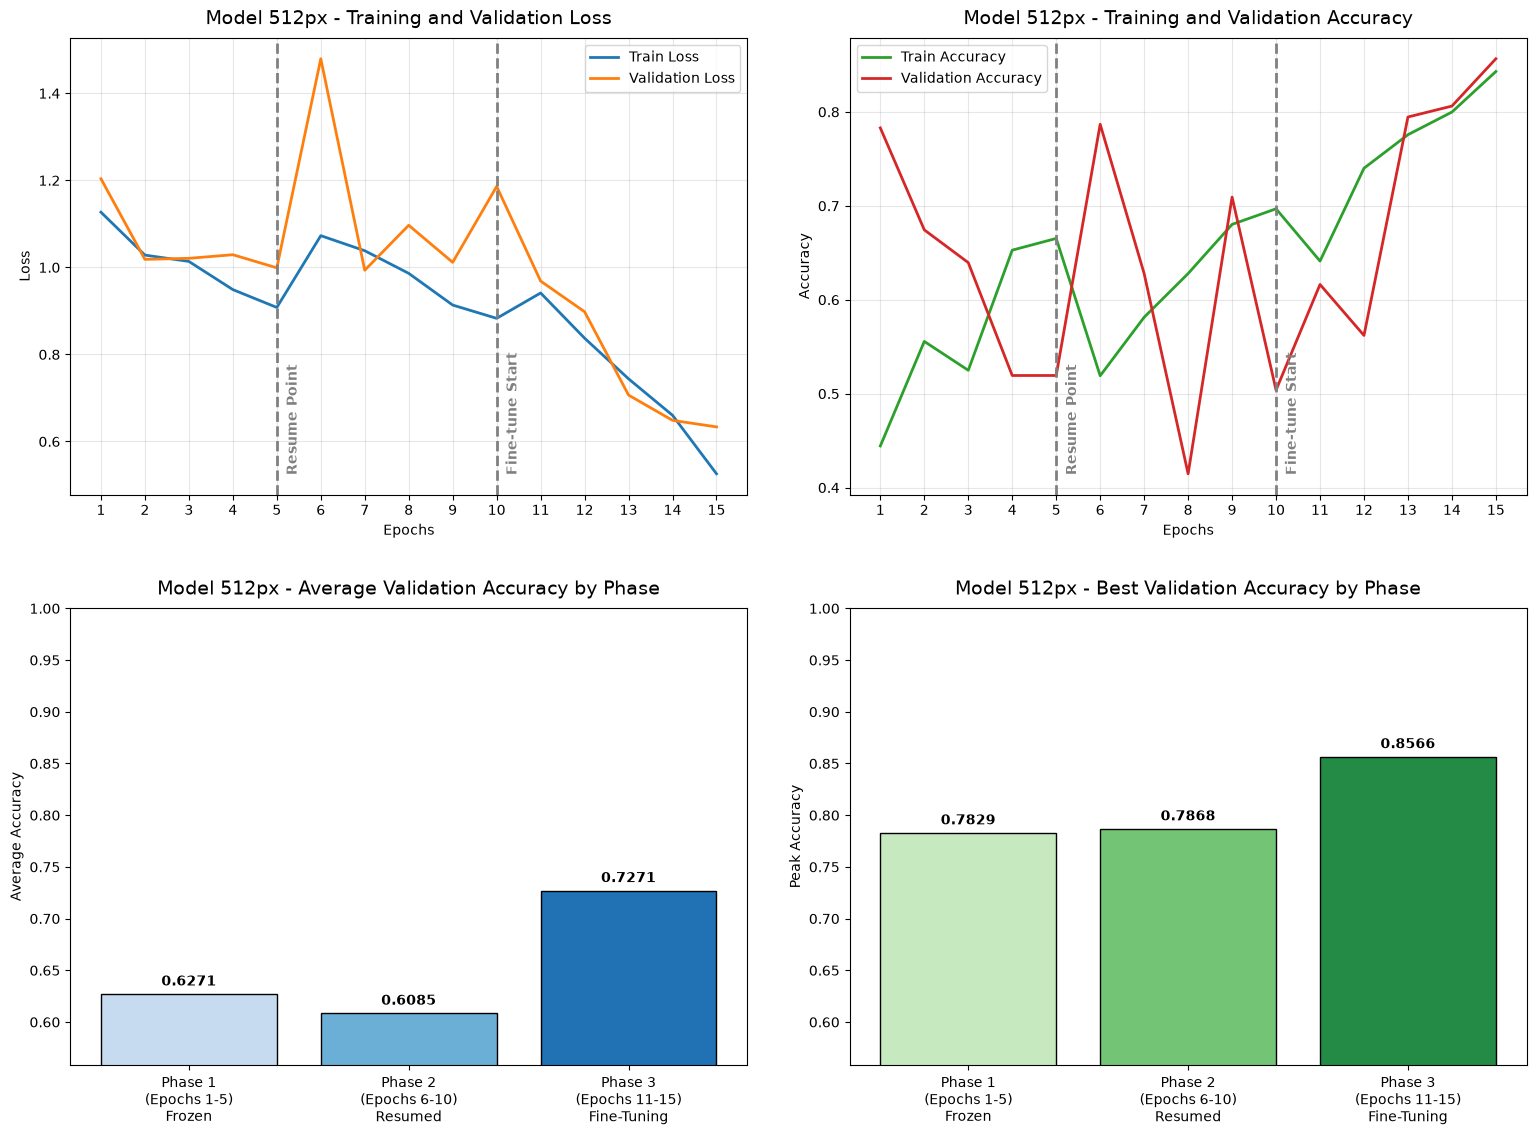

In [207]:
# Consolidate and Plot: 512px Model
history_512 = consolidate_history(history_phase1_512, history_phase2_512, history_phase3_512)
print("=== Generating Plots for 512px Model ===")
plot_training_history(history_512, "Model 512px")

In [208]:
'''
# Consolidate and Plot: 256px Model
history_256 = consolidate_history(history_phase1_256, history_phase2_256, history_phase3_256)
print("\n=== Generating Plots for 256px Model ===")
plot_training_history(history_256, "Model 256px")
'''

'\n# Consolidate and Plot: 256px Model\nhistory_256 = consolidate_history(history_phase1_256, history_phase2_256, history_phase3_256)\nprint("\n=== Generating Plots for 256px Model ===")\nplot_training_history(history_256, "Model 256px")\n'

## Step 6.2: Test Set Evaluation

In [209]:
def evaluate_on_test_set(model, dataloader, device):
    """
    Evaluates the model on the provided dataloader and returns true labels and predictions.
    """
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).float()
            
            # Forward pass
            outputs = model(images).squeeze(-1)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            # Store results
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    return np.array(y_true), np.array(y_pred)

In [210]:
def generate_evaluation_report(y_true, y_pred, model_name):
    """
    Prints the classification report and plots the confusion matrix.
    """
    # Calculate Test Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"=== Evaluation Results: {model_name} ===")
    print(f"{'='*50}")
    print(f"Test Accuracy: {acc:.4f}\n")
    
    # Classification Report
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['No TNT (0)', 'TNT (1)']))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No TNT', 'TNT'], 
                yticklabels=['No TNT', 'TNT'],
                cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=10)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    
    # Save the confusion matrix plot
    file_name = f"images/confusion_matrix_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

Loading final best checkpoint for 512px model...
--- Checkpoint Loaded ---
File: checkpoints/final_best_512.pth
Resumed from Epoch: 5
Saved Training Loss: 0.5258
Saved Validation Acc: 0.8566
Model state restored (Optimizer state skipped).


=== Evaluation Results: Model 512px ===
Test Accuracy: 0.8726

--- Classification Report ---
              precision    recall  f1-score   support

  No TNT (0)       0.97      0.86      0.91       202
     TNT (1)       0.65      0.91      0.76        57

    accuracy                           0.87       259
   macro avg       0.81      0.89      0.84       259
weighted avg       0.90      0.87      0.88       259



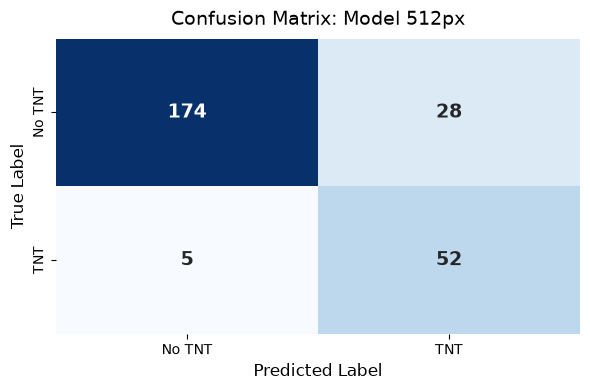

In [211]:
# Evaluate 512px Model
print("Loading final best checkpoint for 512px model...")
load_checkpoint(filepath="checkpoints/final_best_512.pth", model=model_512, device=device)

y_true_512, y_pred_512 = evaluate_on_test_set(model_512, test_loader_512, device)
generate_evaluation_report(y_true_512, y_pred_512, "Model 512px")

In [212]:
'''
# Evaluate 256px Model
print("\nLoading final best checkpoint for 256px model...")
load_checkpoint(filepath="checkpoints/final_best_256.pth", model=model_256, device=device)

y_true_256, y_pred_256 = evaluate_on_test_set(model_256, test_loader_256, device)
generate_evaluation_report(y_true_256, y_pred_256, "Model 256px")
'''

'\n# Evaluate 256px Model\nprint("\nLoading final best checkpoint for 256px model...")\nload_checkpoint(filepath="checkpoints/final_best_256.pth", model=model_256, device=device)\n\ny_true_256, y_pred_256 = evaluate_on_test_set(model_256, test_loader_256, device)\ngenerate_evaluation_report(y_true_256, y_pred_256, "Model 256px")\n'

## Step 6.3: Qualitative Results

In [213]:
def unnormalize(tensor):
    """
    Reverses the ImageNet normalization applied during the dataset creation
    so the image can be properly displayed by matplotlib.
    """
    # ImageNet mean and std
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    
    # Move to CPU and convert to numpy
    img = tensor.cpu().numpy()
    
    # Un-normalize
    img = img * std + mean
    img = np.clip(img, 0, 1) # Ensure pixel values are within [0, 1]
    
    # Transpose from (C, H, W) to (H, W, C) for plotting
    return np.transpose(img, (1, 2, 0))

In [214]:
def plot_qualitative_grid(model, dataloader, device, model_name):
    """
    Generates a 2x4 grid of test patches displaying True/Predicted labels and confidence.
    """
    model.eval()
    
    # Fetch exactly one batch of test data
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    # We only need 8 images for a 2x4 grid
    images = images[:8]
    labels = labels[:8]
    
    with torch.no_grad():
        img_tensors = images.to(device)
        outputs = model(img_tensors).squeeze(-1)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        
    # Setup the 2x4 plot
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(f'Qualitative Results: {model_name}', fontsize=16, fontweight='bold', y=1.02)
    
    for idx, ax in enumerate(axes.flat):
        # Prepare image for display
        img_show = unnormalize(images[idx])
        
        # Get label, prediction, and probability
        true_label = int(labels[idx].item())
        pred_label = int(preds[idx].item())
        prob = probs[idx].item()
        
        # Calculate confidence score for the specific predicted class
        confidence = prob if pred_label == 1 else 1.0 - prob
        
        # Determine text color based on prediction accuracy
        text_color = 'green' if true_label == pred_label else 'red'
        
        # Plot the image patch
        ax.imshow(img_show)
        ax.axis('off')
        
        # Set the title with labels and confidence
        title_text = f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2f}"
        ax.set_title(title_text, color=text_color, fontsize=11, fontweight='bold')
        
    plt.tight_layout()
    
    # Save the figure
    file_name = f"images/qualitative_grid_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

=== Generating 4x4 Test Grid for 512px Model ===


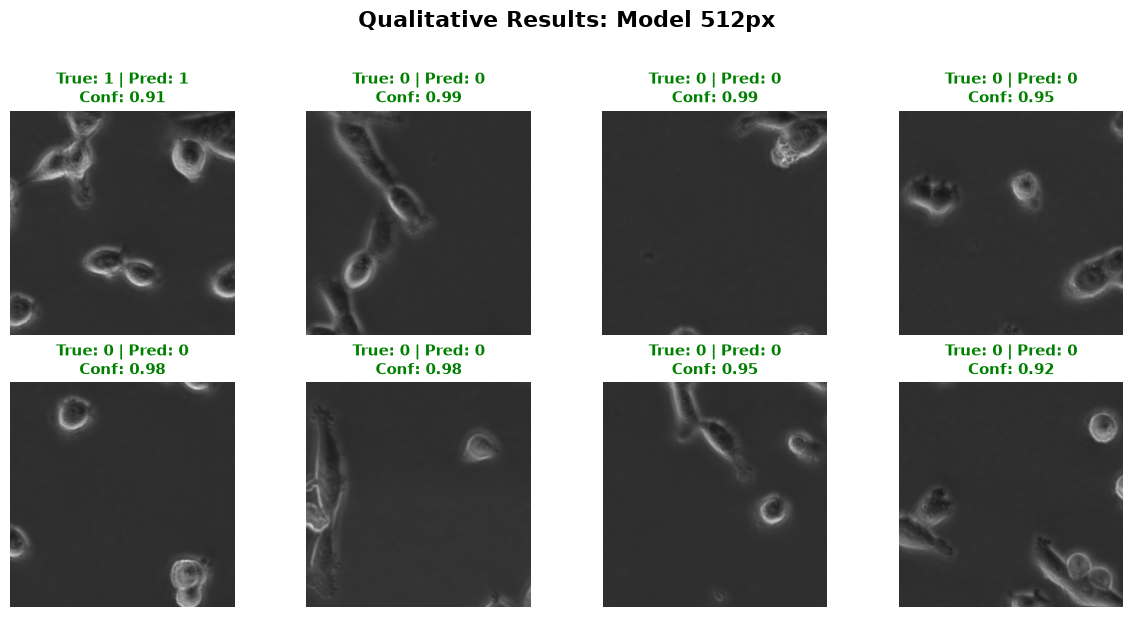

In [215]:
# Qualitative Grid for 512px Model
print("=== Generating 4x4 Test Grid for 512px Model ===")
plot_qualitative_grid(model_512, test_loader_512, device, "Model 512px")

In [216]:
'''
# Qualitative Grid for 256px Model
print("\n=== Generating 4x4 Test Grid for 256px Model ===")
plot_qualitative_grid(model_256, test_loader_256, device, "Model 256px")
'''

'\n# Qualitative Grid for 256px Model\nprint("\n=== Generating 4x4 Test Grid for 256px Model ===")\nplot_qualitative_grid(model_256, test_loader_256, device, "Model 256px")\n'

# STAGE 2: Extracting TNT Patches & Training VGG16 on 256x256 Patches

## Filter TNT Patches

In [ ]:
def extract_filtered_patches(original_path, annotated_path, patch_size, stride, output_dir, model, transform, device):
    """
    Extracts patches from the original image, evaluates them using a pretrained model, 
    and saves ONLY the patches predicted as 'TNT' (prob >= 0.5).
    The saved patches are then sorted into 'tnt' or 'no_tnt' based on the actual ground truth.
    """
    # Setup directories using existing function
    tnt_dir, no_tnt_dir = setup_output_directories(output_dir)
    
    original_img = cv2.imread(original_path)
    annotated_img = cv2.imread(annotated_path)

    if original_img is None or annotated_img is None:
        print("Error: Could not load one or both images.")
        return

    height, width, _ = original_img.shape
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([40, 255, 255])

    # Get sliding window coordinates
    coords = list(get_sliding_window_coords(height, width, patch_size, stride))

    patch_count = 0
    tnt_count = 0
    tnt_coords = []  

    # Ensure model is in evaluation mode
    model.eval()

    print(f"Starting filtered patch extraction for {output_dir}...")
    
    with torch.no_grad():
        for x, y in coords:
            orig_patch = original_img[y:y+patch_size, x:x+patch_size]
            ann_patch = annotated_img[y:y+patch_size, x:x+patch_size]

            # --- Model Prediction (Filter) ---
            # Convert BGR to RGB to match the PIL Image format used in TNTDataset
            orig_patch_rgb = cv2.cvtColor(orig_patch, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(orig_patch_rgb)
            
            # Apply transforms and add batch dimension
            input_tensor = transform(pil_image).unsqueeze(0).to(device)
            
            # Get prediction logit and convert to probability
            output = model(input_tensor).squeeze(-1)
            prob = torch.sigmoid(output).item()
            
            # --- 2. Save only if model predicts TNT ---
            if prob >= 0.5:
                # Check ground truth to sort into correct folders
                is_tnt = contains_full_annotation(ann_patch, lower_yellow, upper_yellow)
                
                if is_tnt:
                    save_dir = tnt_dir
                    tnt_count += 1
                    tnt_coords.append((x, y))
                else:
                    save_dir = no_tnt_dir
                    
                save_path = os.path.join(save_dir, f"patch_{patch_count}.png")
                cv2.imwrite(save_path, orig_patch)
                patch_count += 1

    # Save Random TNT Preview Comparisons
    save_sample_previews(original_img, annotated_img, tnt_coords, patch_size, output_dir, num_samples=5)

    # Report
    no_tnt_count = patch_count - tnt_count
    print(f"Filtered extraction complete for {output_dir}:")
    print(f"  Total patches passing model filter: {patch_count}")
    print(f"  TNT patches (label 1): {tnt_count}")
    print(f"  No TNT patches (label 0): {no_tnt_count}")

## Extract 256×256 patches

In [224]:
# Load best Stage 1 fine-tuned model_512
load_checkpoint(filepath="checkpoints/final_best_512.pth", model=model_512, device=device)

# Run 2: 256x256 patches with stride 64, filtered by model_512
print("Processing 256x256 patches (Filtered by Stage 1 Model)...")
extract_filtered_patches(
    original_path=orig_path,
    annotated_path=ann_path,
    patch_size=256,
    stride=64,
    output_dir="processed_256",
    model=model_512,
    transform=val_test_transform,
    device=device
)

--- Checkpoint Loaded ---
File: checkpoints/final_best_512.pth
Resumed from Epoch: 5
Saved Training Loss: 0.5258
Saved Validation Acc: 0.8566
Model state restored (Optimizer state skipped).

Processing 256x256 patches (Filtered by Stage 1 Model)...
Starting filtered patch extraction for processed_256...
  Saved 5 TNT sample previews to: processed_256\samples
Filtered extraction complete for processed_256:
  Total patches passing model filter: 1228
  TNT patches (label 1): 244
  No TNT patches (label 0): 984


## DataLoaders for 256px

In [225]:
print("\nSetting up 256x256 DataLoaders...")
train_loader_256, val_loader_256, test_loader_256 = create_dataloaders('processed_256', batch_size=batch_size)


Setting up 256x256 DataLoaders...
DataLoaders created for processed_256:
  Train: 4989 samples
  Val:   1069 samples
  Test:  1070 samples


## Load Pretrained Model

In [226]:
model_256 = CustomVGG16().to(device)
print(f"Custom VGG16 Classifier loaded and sent to: {device}")

Custom VGG16 Classifier loaded and sent to: cuda


## Criterion and Loss Function

In [227]:
criterion_256 = compute_criterion('processed_256', device)

optimizer_256 = optim.Adam(
    filter(lambda p: p.requires_grad, model_256.parameters()), lr=0.001
)

## Training Phase 1

In [228]:
gc.collect()
torch.cuda.empty_cache()
os.makedirs("checkpoints", exist_ok=True)

# Train 256 px Model (Phase 1)
print("\n=== Starting Phase 1: 256px Model (Frozen Features) ===")

model_256, optimizer_256, history_phase1_256 = train_phase(
    model=model_256,
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion_256,
    optimizer=optimizer_256,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase1_256.pth"
)


=== Starting Phase 1: 256px Model (Frozen Features) ===
Epoch 1/5
---------------
Train Loss: 1.3224 | Train Acc: 0.4279
Val Loss:   1.2408 | Val Acc:   0.1600
Validation accuracy improved from 0.0000 to 0.1600. Saving...
Checkpoint saved to 'checkpoints/best_phase1_256.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 1.1872 | Train Acc: 0.4674
Val Loss:   1.0807 | Val Acc:   0.4556
Validation accuracy improved from 0.1600 to 0.4556. Saving...
Checkpoint saved to 'checkpoints/best_phase1_256.pth' (Epoch 2)

Epoch 3/5
---------------
Train Loss: 1.0956 | Train Acc: 0.6081
Val Loss:   0.9873 | Val Acc:   0.6922
Validation accuracy improved from 0.4556 to 0.6922. Saving...
Checkpoint saved to 'checkpoints/best_phase1_256.pth' (Epoch 3)

Epoch 4/5
---------------
Train Loss: 1.0627 | Train Acc: 0.6691
Val Loss:   0.9554 | Val Acc:   0.6773

Epoch 5/5
---------------
Train Loss: 0.9779 | Train Acc: 0.6901
Val Loss:   0.9989 | Val Acc:   0.7661
Validation accuracy improved from 0.6922 

## Training Phase 2

In [229]:
gc.collect()
torch.cuda.empty_cache()

# Phase 2: Resume Training - 256px Model
print("\n=== Starting Phase 2: 256px Model (Resume Training) ===")

# Load the best Phase 1 checkpoint (including the optimizer state)
start_epoch_256, loaded_history_256 = load_checkpoint(
    filepath="checkpoints/best_phase1_256.pth",
    model=model_256,
    optimizer=optimizer_256,
    device=device
)

# Continue training for 5 more epochs (Epochs 6-10)
model_256, optimizer_256, history_phase2_256 = train_phase(
    model=model_256,
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion_256,
    optimizer=optimizer_256,
    device=device,
    num_epochs=5,
    save_path="checkpoints/best_phase2_256.pth"
)


=== Starting Phase 2: 256px Model (Resume Training) ===
--- Checkpoint Loaded ---
File: checkpoints/best_phase1_256.pth
Resumed from Epoch: 5
Saved Training Loss: 0.9779
Saved Validation Acc: 0.7661
Optimizer state successfully restored.

Epoch 1/5
---------------
Train Loss: 0.9224 | Train Acc: 0.7286
Val Loss:   0.9648 | Val Acc:   0.8213
Validation accuracy improved from 0.0000 to 0.8213. Saving...
Checkpoint saved to 'checkpoints/best_phase2_256.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 0.8820 | Train Acc: 0.7709
Val Loss:   0.8824 | Val Acc:   0.7774

Epoch 3/5
---------------
Train Loss: 0.8768 | Train Acc: 0.7729
Val Loss:   0.8767 | Val Acc:   0.7493

Epoch 4/5
---------------
Train Loss: 0.8126 | Train Acc: 0.7821
Val Loss:   1.2759 | Val Acc:   0.8868
Validation accuracy improved from 0.8213 to 0.8868. Saving...
Checkpoint saved to 'checkpoints/best_phase2_256.pth' (Epoch 4)

Epoch 5/5
---------------
Train Loss: 0.8434 | Train Acc: 0.7921
Val Loss:   0.8215 | Va

## Fine-Tuning Phase 3

In [230]:
gc.collect()
torch.cuda.empty_cache()

# Phase 3: Fine-Tuning - 256px Model
print("\n=== Starting Phase 3: 256px Model (Fine-Tuning) ===")
model_256, history_phase3_256 = unfreeze_and_finetune(
    model=model_256,
    filepath_load="checkpoints/best_phase2_256.pth",
    filepath_save="checkpoints/final_best_256.pth",
    train_loader=train_loader_256,
    val_loader=val_loader_256,
    criterion=criterion_256,
    device=device
)


=== Starting Phase 3: 256px Model (Fine-Tuning) ===
--- Checkpoint Loaded ---
File: checkpoints/best_phase2_256.pth
Resumed from Epoch: 4
Saved Training Loss: 0.8126
Saved Validation Acc: 0.8868
Model state restored (Optimizer state skipped).

Epoch 1/5
---------------
Train Loss: 1.0423 | Train Acc: 0.7464
Val Loss:   0.7595 | Val Acc:   0.8812
Validation accuracy improved from 0.0000 to 0.8812. Saving...
Checkpoint saved to 'checkpoints/final_best_256.pth' (Epoch 1)

Epoch 2/5
---------------
Train Loss: 0.8801 | Train Acc: 0.7939
Val Loss:   0.7694 | Val Acc:   0.8793

Epoch 3/5
---------------
Train Loss: 0.9127 | Train Acc: 0.8266
Val Loss:   0.8496 | Val Acc:   0.9214
Validation accuracy improved from 0.8812 to 0.9214. Saving...
Checkpoint saved to 'checkpoints/final_best_256.pth' (Epoch 3)

Epoch 4/5
---------------
Train Loss: 0.7134 | Train Acc: 0.8609
Val Loss:   4.9035 | Val Acc:   0.8457

Epoch 5/5
---------------
Train Loss: 1.2789 | Train Acc: 0.7921
Val Loss:   0.6976 |

## Comprehensive Plots


=== Generating Plots for 256px Model ===
Figure saved successfully as 'images/training_history_model_256px.png' with DPI=300.


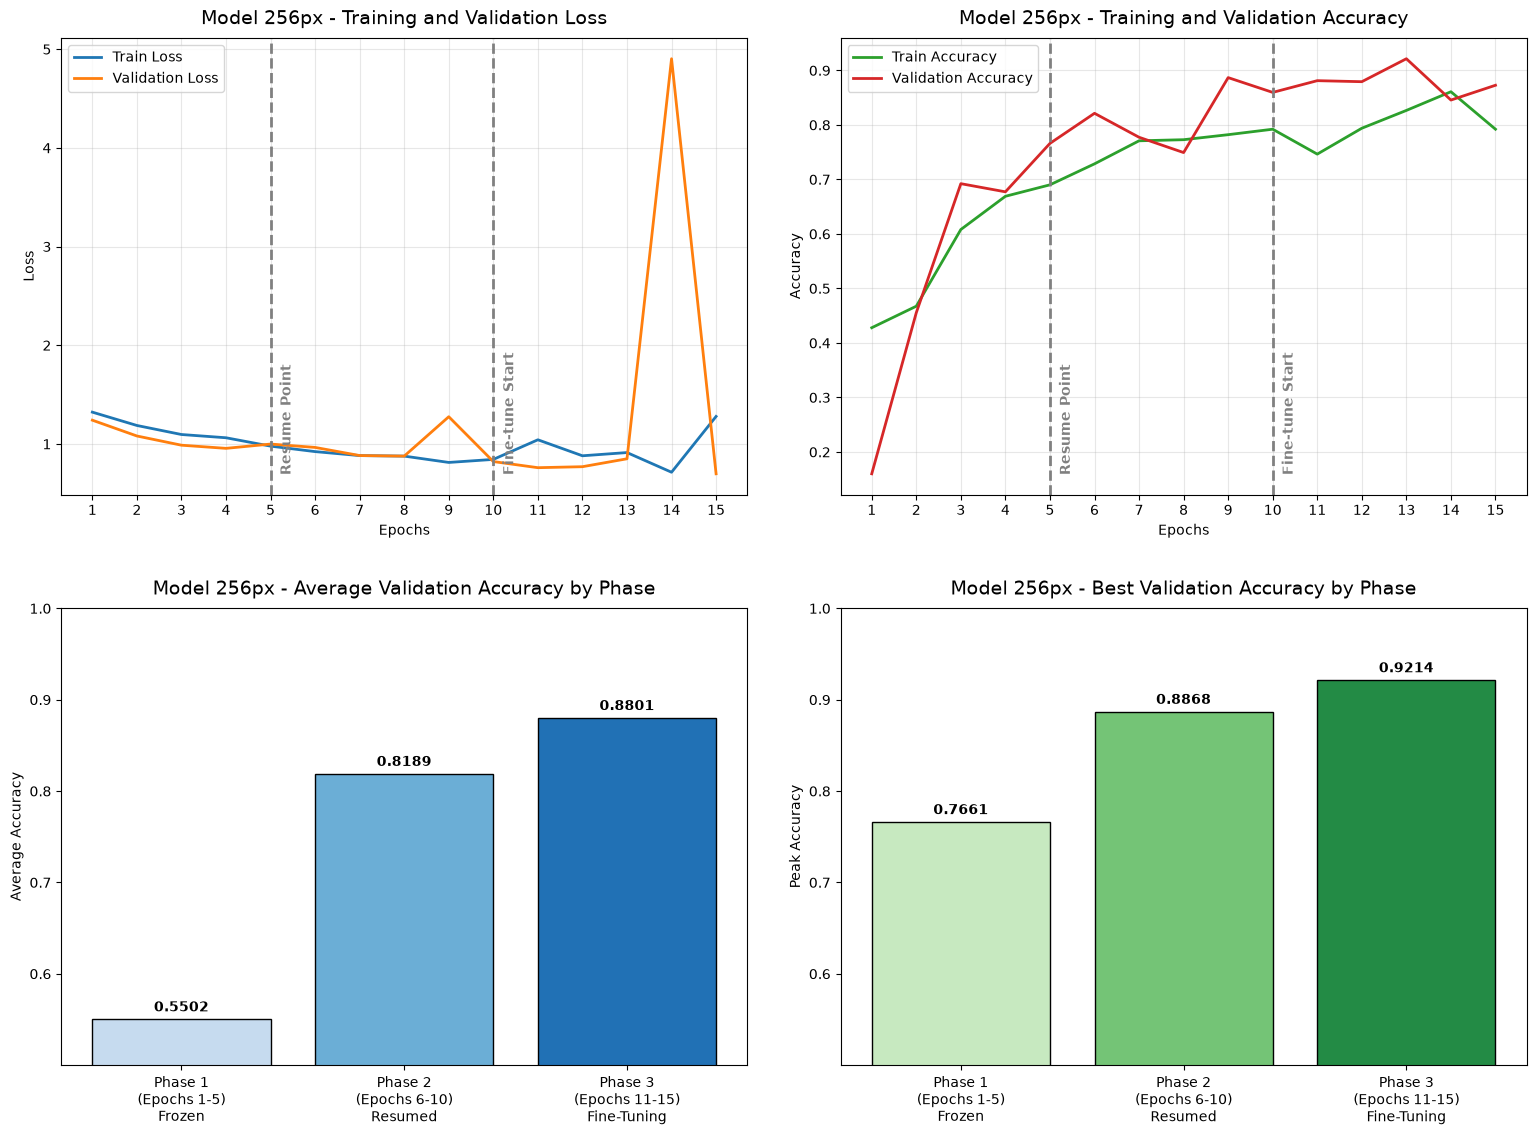

In [231]:
# Consolidate and Plot: 256px Model
history_256 = consolidate_history(history_phase1_256, history_phase2_256, history_phase3_256)
print("\n=== Generating Plots for 256px Model ===")
plot_training_history(history_256, "Model 256px")

## Test Set Evaluation


Loading final best checkpoint for 256px model...
--- Checkpoint Loaded ---
File: checkpoints/final_best_256.pth
Resumed from Epoch: 3
Saved Training Loss: 0.9127
Saved Validation Acc: 0.9214
Model state restored (Optimizer state skipped).


=== Evaluation Results: Model 256px ===
Test Accuracy: 0.9084

--- Classification Report ---
              precision    recall  f1-score   support

  No TNT (0)       0.96      0.94      0.95       974
     TNT (1)       0.49      0.61      0.55        96

    accuracy                           0.91      1070
   macro avg       0.73      0.78      0.75      1070
weighted avg       0.92      0.91      0.91      1070



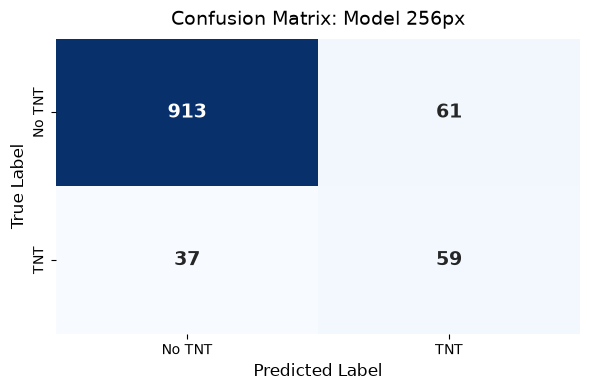

In [232]:
# Evaluate 256px Model
print("\nLoading final best checkpoint for 256px model...")
load_checkpoint(filepath="checkpoints/final_best_256.pth", model=model_256, device=device)

y_true_256, y_pred_256 = evaluate_on_test_set(model_256, test_loader_256, device)
generate_evaluation_report(y_true_256, y_pred_256, "Model 256px")

## Qualitative Results


=== Generating 4x4 Test Grid for 256px Model ===


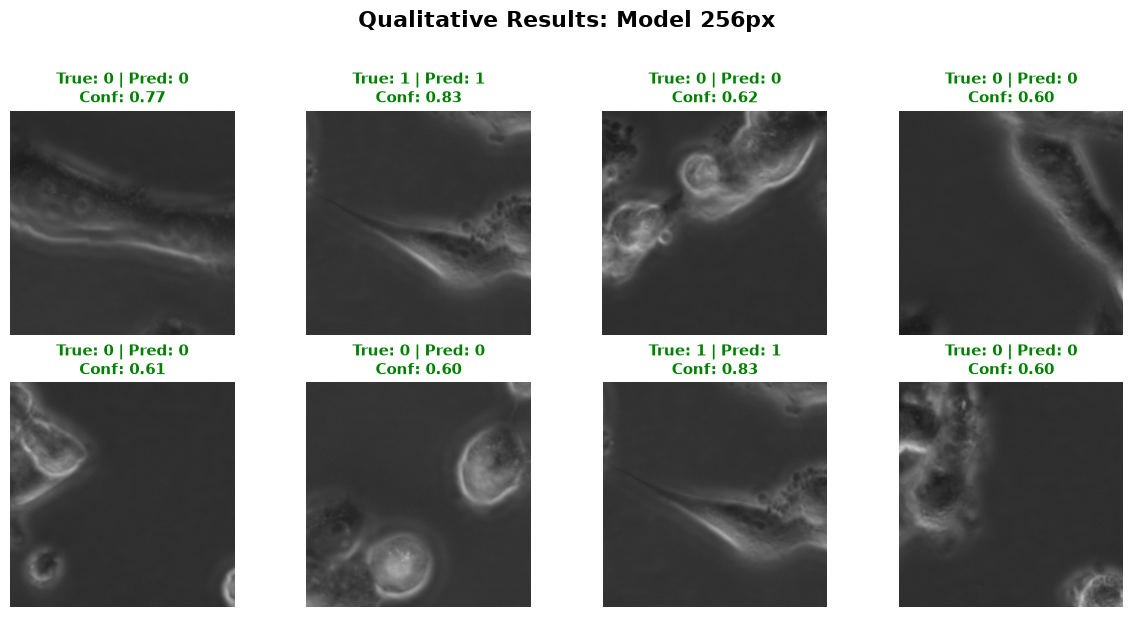

In [233]:
# Qualitative Grid for 256px Model
print("\n=== Generating 4x4 Test Grid for 256px Model ===")
plot_qualitative_grid(model_256, test_loader_256, device, "Model 256px")

# STAGE 3: U-Net Segmentation in 256px Images

## Filter TNT Patches from STAGE 2 Model

In [ ]:
def extract_stage2_tnt_patches(model, dataloader, dataset, original_annotated_dir, output_dir, device):
    """
    Evaluates the Stage 2 model on the dataloader and extracts patches 
    predicted as TNT (1) into a new directory structure for Stage 3.
    Tracks actual ground truth distributions of the filtered outputs.
    """
    tnt_dir, no_tnt_dir = setup_output_directories(output_dir)
    
    mask_dir = os.path.join(output_dir, 'masks')
    os.makedirs(mask_dir, exist_ok=True)
    
    model.eval()
    patch_count = 0
    tnt_count = 0
    
    with torch.no_grad():
        for i, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            outputs = model(images).squeeze(-1)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            for j, pred in enumerate(preds):
                if pred.item() == 1.0:
                    img_path = dataset.image_paths[i * dataloader.batch_size + j]
                    filename = os.path.basename(img_path)
                    
                    dest_path = os.path.join(tnt_dir, filename)
                    shutil.copy(img_path, dest_path)
                    
                    patch_count += 1
                    
                    # Track ground truth label of the predicted patch
                    if labels[j].item() == 1.0:
                        tnt_count += 1

    no_tnt_count = patch_count - tnt_count
    print(f"Filtered extraction complete for {output_dir}:")
    print(f"  Total patches passing model filter: {patch_count}")
    print(f"  TNT patches (label 1): {tnt_count}")
    print(f"  No TNT patches (label 0): {no_tnt_count}")

## Extract patches

In [ ]:
# Load best Stage 2 fine-tuned model_256
load_checkpoint(filepath="checkpoints/final_best_256.pth", model=model_256, device=device)

# Run Stage 3: Extract TNT patches from Stage 2 outputs
print("Processing 256x256 patches (Filtered by Stage 2 Model)...")
extract_stage2_tnt_patches(model_256, test_loader_256, base_dataset_256, "processed_256", "segmentation_256", device)

## Load Pretrained Model

In [235]:
# Attention U-Net with a pretrained ResNet-34 encoder
model = smp.Unet(
    # ResNet-34 backbone
    encoder_name="resnet34",
    # ImageNet pretrained weights
    encoder_weights="imagenet",
    # Channels RGB
    in_channels=3,
    classes=64,
    activation=None,
    # Adds attention (SCSE blocks)
    decoder_attention_type="scse"
)

print("--- Attention U-Net Architecture ---")
# Example using the 256x256 patch size for the structural summary
summary(model, input_size=(1, 3, 256, 256))

--- Attention U-Net Architecture ---


Layer (type:depth-idx)                                       Output Shape              Param #
Unet                                                         [1, 64, 256, 256]         --
├─ResNetEncoder: 1-1                                         [1, 3, 256, 256]          --
│    └─Conv2d: 2-1                                           [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                                      [1, 64, 128, 128]         128
│    └─ReLU: 2-3                                             [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                                        [1, 64, 64, 64]           --
│    └─Sequential: 2-5                                       [1, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                                  [1, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-2                                  [1, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-3                                  [1, 64, 64, 64]       